In [35]:
import sys
import os

project_root = "/scratch/network/dd6849/rpmml-project/rpmml-project/src"
sys.path.append(project_root)

print(sys.path)


['/home/dd6849/.conda/envs/diffuserClean/lib/python310.zip', '/home/dd6849/.conda/envs/diffuserClean/lib/python3.10', '/home/dd6849/.conda/envs/diffuserClean/lib/python3.10/lib-dynload', '', '/home/dd6849/.conda/envs/diffuserClean/lib/python3.10/site-packages', '/scratch/network/dd6849/rpmml-project/rpmml-project/src', '/tmp/tmplgo2nklh', '/scratch/network/dd6849/rpmml-project/rpmml-project/src', '/scratch/network/dd6849/rpmml-project/rpmml-project/src']


In [36]:
import matplotlib.pyplot as plt
import numpy as np
import random
from rpmml_project.pointmaze.point_maze_skip import  MinariTrajectoryDatasetWithPseudoActions, EqNet, GaussianDiffusion, DiffuserTrainer, DiffuserPlanner, CompositeReward, expand_spline_from_skip_list, StartReachingReward, GoalReachingReward, SkipTotalTimeSkipPenalty, CurvaturePenalty
import torch
from matplotlib.patches import Rectangle
import mujoco

In [37]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

USE_POSITIONAL_ENCODING = False

print("\n" + "=" * 80)
print("EQ-NET CONFIGURATION")
print("=" * 80)
print(f"Positional Encoding: {USE_POSITIONAL_ENCODING}")
print("Architecture: Local convolutions (no downsampling) for shift equivariance")
print("Using MinariTrajectoryDatasetWithPseudoActions (pos + skip as action)")

    # ========================================================================
    # DATA
    # ========================================================================

# Use pseudo-action dataset
dataset = MinariTrajectoryDatasetWithPseudoActions(
    "D4RL/pointmaze/umaze-v2", horizon=32, n_chunks_frac= 0.5
)
print(f"\nDataset size: {len(dataset)} trajectory windows")
print(f"Trajectory dim (pos+skip): {dataset.traj_dim}")

    

Using device: cuda

EQ-NET CONFIGURATION
Positional Encoding: False
Architecture: Local convolutions (no downsampling) for shift equivariance
Using MinariTrajectoryDatasetWithPseudoActions (pos + skip as action)

Dataset size: 171693 trajectory windows
Trajectory dim (pos+skip): 3


In [38]:
# ========================================================================
    # MODEL
    # ========================================================================

eqnet = EqNet(
        state_dim=dataset.traj_dim,
        hidden_dim=128,
        time_dim=32,
        n_layers=10,  # Deep but local
    )

diffusion = GaussianDiffusion(timesteps=200)

print(f"\nModel parameters: {sum(p.numel() for p in eqnet.parameters()):,}")


Model parameters: 1,506,179


In [39]:
# ========================================================================
# TRAINING
# ========================================================================

trainer = DiffuserTrainer(
        model = eqnet,
        diffusion = diffusion,
        dataset=dataset,
        device = device,
    )

TRAIN_NEW = False
if TRAIN_NEW:
    print("\n" + "=" * 80)
    print("TRAINING")
    print("=" * 80)
    trainer.train(epochs=100, save_every=1)
else:
    print("\nLoading pre-trained model...")
    try:
        trainer.load("/scratch/network/dd6849/rpmml-project/checkpoints/diffuser_flat_eqnet_epoch_100.pt")
        print("Loaded checkpoint successfully")
    except:
        print("No checkpoint found, using random initialization")

trainer.use_ema_for_inference()



Loading pre-trained model...
Loaded checkpoint successfully
Switched to EMA parameters for inference


In [40]:
# ========================================================================
# PLANNING
# ========================================================================

planner = DiffuserPlanner(eqnet, diffusion, dataset, device=device)

current = np.array([-1, -1, 0.88507522, 4.78210334])
goal = np.array([0.55692841, 1.02245092])

reward_fn = CompositeReward(
    [
        StartReachingReward(current[:2], reward_scale=5.0),
        GoalReachingReward(goal, reward_scale=5.0),
        SkipTotalTimeSkipPenalty(reward_scale=0.1),
        CurvaturePenalty(reward_scale=0.1),
    ]
)

print("\n" + "=" * 80)
print("PLANNING WITH EQ-NET (pos + skip)")
print("=" * 80)

# Experiment 1: standard planning
print("\n--- Experiment 1: Standard Planning ---")
traj = planner.plan_and_reconstruct(
    current,
    goal,
    reward_fn=reward_fn,
    horizon=64,
    guidance_scale=2.0,
    condition_on_start=True,
    condition_on_goal=False,
    conditioning_schedule="cosine",
    conditioning_strength=0.9,
    spline_func=expand_spline_from_skip_list,
)
coarse, = traj["coarse"],
coarse_pos= traj["coarse_pos"] 
coarse_skip=traj["coarse_skip"]              # (H,)
skip = traj["skip_list"]     # [(pos_i, skip_i)]
pos_dense=traj["pos_dense"]           # (N,2)
vel_dense=traj["vel_dense"]           # (N,2)
acc_dense=traj["acc_dense"]           # (N,2)  
print(f"Start (actual): {pos_dense[0]}")
print(f"Start (target): {current[:2]}")
print(f"Start error: {np.linalg.norm(pos_dense[0] - current[:2]):.4f}")
print(f"End: {pos_dense[-1]}")
print(f"Goal: {goal}")
print(f"Goal error: {np.linalg.norm(pos_dense[-1] - goal):.4f}")
print("\n" + "=" * 80)
print("EXPERIMENTS COMPLETE")
print("=" * 80)
print(pos_dense)


PLANNING WITH EQ-NET (pos + skip)

--- Experiment 1: Standard Planning ---
Start (actual): [-1.00407992 -0.99743283]
Start (target): [-1. -1.]
Start error: 0.0048
End: [0.5369923  1.06256497]
Goal: [0.55692841 1.02245092]
Goal error: 0.0448

EXPERIMENTS COMPLETE
[[-1.00407992e+00 -9.97432826e-01]
 [-9.82845376e-01 -9.97188581e-01]
 [-9.45018931e-01 -9.97289162e-01]
 [-9.07963702e-01 -9.98207491e-01]
 [-8.69323296e-01 -9.98862330e-01]
 [-8.36122682e-01 -9.99004555e-01]
 [-8.01192546e-01 -9.99293532e-01]
 [-7.56639355e-01 -9.99779756e-01]
 [-7.10857207e-01 -1.00051914e+00]
 [-6.69066669e-01 -1.00172547e+00]
 [-6.26652289e-01 -1.00249779e+00]
 [-5.75674738e-01 -1.00266074e+00]
 [-5.25138275e-01 -1.00278187e+00]
 [-4.84705152e-01 -1.00289233e+00]
 [-4.45095189e-01 -1.00287558e+00]
 [-4.01971186e-01 -1.00285641e+00]
 [-3.60537152e-01 -1.00241825e+00]
 [-3.30830235e-01 -1.00154681e+00]
 [-3.01294333e-01 -1.00079377e+00]
 [-2.66907356e-01 -1.00016742e+00]
 [-2.34762666e-01 -9.99486203e-01]
 

In [41]:
env = dataset.dataset.recover_environment()

def unwrap_env(env):
    while hasattr(env, "env"):
        env = env.env
    return env

env = unwrap_env(env)

mj_model = env.model
mj_data = env.data

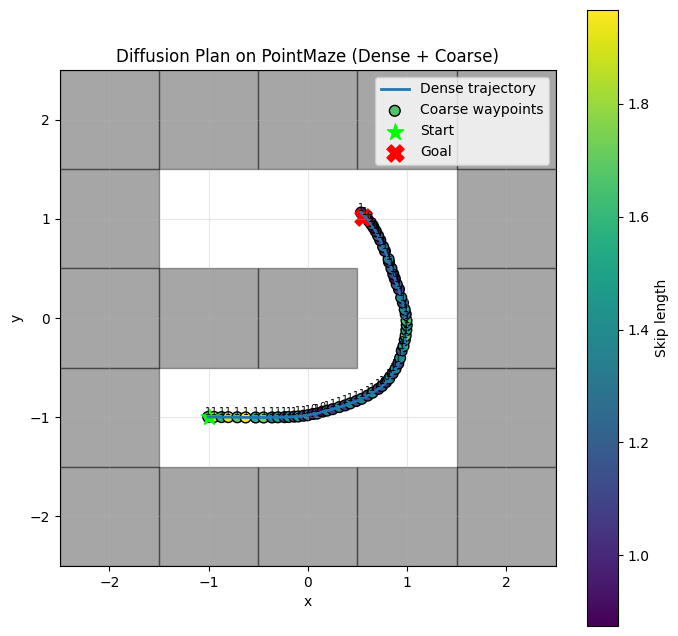

In [42]:

# Create figure
fig, ax = plt.subplots(figsize=(8, 8))

# ===========================================================
# 1) Dense trajectory
# ===========================================================
ax.plot(
    pos_dense[:, 0],
    pos_dense[:, 1],
    linewidth=2,
    color="tab:blue",
    label="Dense trajectory"
)

# ===========================================================
# 2) Coarse waypoints (colored by skip)
# ===========================================================
sc = ax.scatter(
    coarse_pos[:, 0],
    coarse_pos[:, 1],
    c=coarse_skip,
    s=60,
    cmap="viridis",
    edgecolors="k",
    label="Coarse waypoints"
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Skip length")

# Annotate skip values
for i, (x, y) in enumerate(coarse_pos):
    ax.text(x, y, f"{int(coarse_skip[i])}", fontsize=7, ha="center", va="bottom")

# ===========================================================
# 3) Start and Goal
# ===========================================================
ax.scatter(current[0], current[1], s=150, marker="*", color="lime",  label="Start")
ax.scatter(goal[0],    goal[1],    s=150, marker="X", color="red",   label="Goal")

# ===========================================================
# 4) Render MuJoCo maze walls
# ===========================================================
for geom_id in range(mj_model.ngeom):

    name = mujoco.mj_id2name(mj_model, mujoco.mjtObj.mjOBJ_GEOM, geom_id)

    if name is None or ("block" not in name):
        continue

    pos = mj_model.geom_pos[geom_id]      # (x,y,z) center
    size = mj_model.geom_size[geom_id]    # half sizes (hx,hy,hz)

    cx, cy = pos[:2]
    hx, hy = size[:2]

    rect = Rectangle(
        (cx - hx, cy - hy),
        2 * hx,
        2 * hy,
        color="black",
        alpha=0.35,
        zorder=0
    )
    ax.add_patch(rect)

# ===========================================================
# Final styling
# ===========================================================
ax.set_title("Diffusion Plan on PointMaze (Dense + Coarse)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal", "box")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")

# Mazes are usually within [-2.5, 2.5]
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)

plt.show()
